# Imputation experiments (SQ1/SQ2)


## 1. Path setup + dataset

In [1]:
# ---------------------------------------------------------------------------
# Path setup + dataset switch. This is the ONLY cell you change between
# datasets: set DATASET to a key registered in common.datasets.
# ---------------------------------------------------------------------------
import sys
from pathlib import Path

DATASET = "scenario33"          # "scenario5" | "scenario33"


def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "data").is_dir():
            return parent
    return start.parent


REPO_ROOT   = _find_repo_root(Path.cwd())
SRC         = REPO_ROOT / "src"
RESULTS_DIR = REPO_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
CSV_DIR     = RESULTS_DIR / "csv"
TUNED_PARAMS_PATH = RESULTS_DIR / "tuned_params.json"
for _d in (FIGURES_DIR, CSV_DIR):
    _d.mkdir(parents=True, exist_ok=True)

_diffputer = REPO_ROOT / "external" / "DiffPuter"
for _p in (REPO_ROOT, SRC,
           _diffputer / "baselines" / "GRAPE",
           _diffputer / "baselines",
           _diffputer):
    _sp = str(_p.resolve())
    if _p.exists() and _sp not in sys.path:
        sys.path.insert(0, _sp)

from common.datasets import get_dataset

spec = get_dataset(DATASET)
DATA_DIR = REPO_ROOT / "data" / spec.data_dirname
print(f"Dataset: {spec.name}")

print("DATA_DIR:", DATA_DIR)

Dataset: scenario33
DATA_DIR: /mnt/c/Users/Kenneth Chan/Documents/School/Research Project/Repo/ImputationFor6GDatasets/data/Scenario33


In [2]:
# Check environment and imports
from common.environment import check_environment
check_environment()
# Enable automatic reloading of edited modules in this notebook
%load_ext autoreload
%autoreload 2

Required packages
------------------------------------------------------------
  ✓ numpy              OK       1.26.4
  ✓ pandas             OK       2.3.3
  ✓ scipy              OK       1.17.1
  ✓ scikit-learn       OK       1.6.1
  ✓ matplotlib         OK       3.10.9
  ✓ statsmodels        OK       0.14.6
  ✓ fancyimpute        OK       0.7.0
  ✓ hyperimpute        OK       0.1.17
  ✓ torch              OK       2.4.1
  ✓ torch_geometric    OK       2.7.0
  ✓ h5py               OK       3.14.0
  ✓ networkx           OK       3.6.1


I0000 00:00:1780912756.862657     839 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


  ✓ POT                OK       0.9.6.post1
  ✓ FrEIA              OK       0.2
  ✓ timm               OK       1.0.27
  ✓ PyYAML             OK       6.0.3
  ✓ ipykernel          OK       7.2.0

Optional packages
------------------------------------------------------------
  ✓ torch_scatter      OK       2.1.2+pt24cu121

Smoke-test imports for imputation APIs
------------------------------------------------------------
  ✓ Mean / kNN (sklearn): OK
  ✓ MICE (sklearn IterativeImputer): OK
  ✓ SoftImpute / KNN / SimpleFill (fancyimpute): OK
  ✓ HyperImpute (hyperimpute.plugins.imputers.Imputers): OK
  ✓ PyTorch Geometric (for GRAPE): OK

Local repo modules (DiffPuter / GRAPE)
------------------------------------------------------------
  ✓ DiffPuter dataset: OK (dataset)
  ✓ DiffPuter diffusion: OK (diffusion_utils)
  ✓ DiffPuter model: OK (model)
  ✓ GRAPE training: OK (training.gnn_mdi)

All required packages present.


## 2. Dataset analysis (raw)

In [3]:
import pandas as pd
import numpy as np

# Raw CSV exploration (pre-cleaning), purely informational.
df = pd.read_csv(DATA_DIR / spec.raw_csv_name)
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (3981, 20)

Columns: ['index', 'unit1_rgb', 'unit1_pwr_60ghz', 'unit1_lidar', 'unit1_radar', 'unit1_loc', 'unit2_loc', 'unit1_beam', 'unit1_max_pwr', 'time_stamp', 'seq_index', 'unit2_spd_over_grnd_kmph', 'unit2_num_sats', 'unit2_altitude', 'unit2_geo_sep', 'unit2_mode_fix_type', 'unit2_pdop', 'unit2_hdop', 'unit2_vdop', 'unit2_interpolated_position']

Missing values:
index                            0
unit1_rgb                        0
unit1_pwr_60ghz                  0
unit1_lidar                      0
unit1_radar                      0
unit1_loc                        0
unit2_loc                        0
unit1_beam                       0
unit1_max_pwr                    0
time_stamp                       0
seq_index                        0
unit2_spd_over_grnd_kmph       302
unit2_num_sats                 302
unit2_altitude                 302
unit2_geo_sep                  302
unit2_mode_fix_type            302
unit2_pdop                     302
unit2_hdop                 

,index,unit1_rgb,unit1_pwr_60ghz,unit1_lidar,unit1_radar,unit1_loc,unit2_loc,unit1_beam,unit1_max_pwr,time_stamp,seq_index,unit2_spd_over_grnd_kmph,unit2_num_sats,unit2_altitude,unit2_geo_sep,unit2_mode_fix_type,unit2_pdop,unit2_hdop,unit2_vdop,unit2_interpolated_position
0,1,./unit1/camera_data/image_1.jpg,./unit1/mmWave_data/mmWave_power_1.txt,./unit1/lidar_data/lidar_data_1.ply,./unit1/radar_data/radar_data_1.npy,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/GPS_location_1.txt,3,0.419048,04:09:06-325991,1,7.997,12.0,355.907,-27.749,3.0,1.06,0.59,0.88,0
1,2,./unit1/camera_data/image_2.jpg,./unit1/mmWave_data/mmWave_power_2.txt,./unit1/lidar_data/lidar_data_2.ply,./unit1/radar_data/radar_data_2.npy,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/GPS_location_2.txt,2,0.530836,04:09:06-418775,1,7.676,12.0,355.905,-27.749,3.0,1.06,0.59,0.88,0
2,3,./unit1/camera_data/image_3.jpg,./unit1/mmWave_data/mmWave_power_3.txt,./unit1/lidar_data/lidar_data_3.ply,./unit1/radar_data/radar_data_3.npy,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/GPS_location_3.txt,4,0.558496,04:09:06-510460,1,7.560,12.0,355.900,-27.749,3.0,1.06,0.59,0.88,0
3,4,./unit1/camera_data/image_4.jpg,./unit1/mmWave_data/mmWave_power_4.txt,./unit1/lidar_data/lidar_data_4.ply,./unit1/radar_data/radar_data_4.npy,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/GPS_location_4.txt,3,0.458776,04:09:06-601724,1,7.347,12.0,355.897,-27.749,3.0,1.06,0.59,0.88,0
4,5,./unit1/camera_data/image_5.jpg,./unit1/mmWave_data/mmWave_power_5.txt,./unit1/lidar_data/lidar_data_5.ply,./unit1/radar_data/radar_data_5.npy,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/GPS_location_5.txt,3,0.392710,04:09:06-693246,1,7.365,12.0,355.890,-27.749,3.0,1.06,0.59,0.88,0


## 3. Load clean data

Parsing + column drops are handled by the dataset's loader.

In [4]:
clean_data = spec.loader(DATA_DIR)
clean_data.head()

Parsing location files...
Parsing mmWave power files...
Argmax matches unit1_beam: 100.00%
Parsed shape: (3981, 71)  |  missing cells: 1270
Dropped 338 incomplete row(s) (3981 -> 3643); experiments require fully observed input.
Clean data shape: (3643, 71)


,beam_00,beam_01,beam_02,beam_03,beam_04,beam_05,beam_06,beam_07,beam_08,beam_09,...,beam_61,beam_62,beam_63,seq_index,unit2_num_sats,unit2_pdop,unit2_hdop,unit2_vdop,unit2_lat,unit2_lon
0,0.125130,0.414454,0.419048,0.377053,0.253087,0.237396,0.234841,0.193210,0.166630,0.175977,...,0.148922,0.142658,0.139798,1,12.0,1.06,0.59,0.88,33.424323,-111.935202
1,0.299215,0.530836,0.521273,0.469569,0.428347,0.378383,0.304954,0.272232,0.206698,0.206097,...,0.165791,0.149135,0.138260,1,12.0,1.06,0.59,0.88,33.424323,-111.935199
2,0.243646,0.480637,0.517254,0.558496,0.540418,0.485928,0.382671,0.343157,0.222359,0.215955,...,0.183378,0.156578,0.158700,1,12.0,1.06,0.59,0.88,33.424323,-111.935197
3,0.296607,0.455700,0.458776,0.457767,0.426886,0.434324,0.419639,0.383213,0.303191,0.294355,...,0.162988,0.156579,0.146286,1,12.0,1.06,0.59,0.88,33.424323,-111.935195
4,0.298207,0.375788,0.392710,0.362264,0.339000,0.347357,0.324467,0.284371,0.213134,0.200486,...,0.156158,0.147029,0.141561,1,12.0,1.06,0.59,0.88,33.424323,-111.935193


# Amputation experiments: MCAR, MAR, and MNAR

In [5]:
from imputers.imputers import (
    MeanImputer, KNNImputerWrapper, MICEImputer,
    SoftImputeWrapper, HyperImputeImputer,
)
from imputers.diffputer_imputer import DiffPuterImputer
from imputers.grape_imputer import GRAPEImputer

from common.experiment import ExperimentConfig, run_experiments

In [6]:
# ---------------------------------------------------------------------------
# Configuration — built from the dataset spec.
# ---------------------------------------------------------------------------
cfg = ExperimentConfig(
    target_cols=spec.target_cols,
    retained_cols=spec.retained_cols,
    mar_driver_cols=spec.mar_driver_cols,
    mar_score_mode=spec.mar_score_mode,
    proportions=[0.10, 0.30, 0.50],
    n_seeds=3,
)

# Run experiments

In [7]:
from common.tuning import load_tuned_params

# Load the SAME tuned params used downstream so the two tables stay comparable.
# Index keys directly and assert presence: a missing tuned value should fail
# loudly, not silently fall back to a library default.
tp = load_tuned_params(TUNED_PARAMS_PATH, spec.name)
assert tp, (f"No tuned params for '{spec.name}' in {TUNED_PARAMS_PATH}. "
            f"Run tuning.ipynb with DATASET='{spec.name}' first.")
for _k in ("knn_n_neighbors", "softimpute_shrinkage", "diffputer",
           "grape_epochs", "grape_node_edge_dim", "grape_lr"):
    assert _k in tp, f"tuned_params.json missing key '{_k}' for {spec.name}."
print("Loaded tuned params:",
      {k: ("{...}" if isinstance(v, dict) else v) for k, v in tp.items()})

mean        = MeanImputer()
knn         = KNNImputerWrapper(k=tp["knn_n_neighbors"])
mice        = MICEImputer()
softimpute  = SoftImputeWrapper(shrinkage_value=tp["softimpute_shrinkage"])
hyperimpute = HyperImputeImputer()
diffputer   = DiffPuterImputer(**tp["diffputer"])
grape       = GRAPEImputer(epochs=tp["grape_epochs"],
                           node_dim=tp["grape_node_edge_dim"],
                           edge_dim=tp["grape_node_edge_dim"],
                           lr=tp["grape_lr"])

imputers = [mean, knn, mice, softimpute, hyperimpute, diffputer, grape]

Loaded tuned params: {'knn_n_neighbors': 5, 'softimpute_shrinkage': 3.5984, 'diffputer': '{...}', 'grape_epochs': 20000, 'grape_node_edge_dim': 128, 'grape_lr': 0.0014419212885994892}


In [8]:
RECON_CSV = CSV_DIR / f"{spec.name}_imputation_results.csv"
scenario_filter = ["MCAR", "MAR", "MNAR", "MCAR-Row"]
results_df, summary_df = run_experiments(
    clean_data, config=cfg, imputers=imputers,
    scenario_filter=scenario_filter, verbose=True,
    results_csv=RECON_CSV,
)
display(summary_df)

Filtered to 4 scenario(s): ['MCAR', 'MAR', 'MNAR', 'MCAR-Row']
Resuming: 186 run(s) already in scenario33_imputation_results.csv.
Total runs: 252 (4 scenarios x 3 props x 7 methods x 3 seeds)
  [3/252] MCAR | p=0.1 | Mean: cached, skipped 3 seed(s)
  [6/252] MCAR | p=0.1 | kNN: cached, skipped 3 seed(s)
  [9/252] MCAR | p=0.1 | MICE: cached, skipped 3 seed(s)
  [12/252] MCAR | p=0.1 | SoftImpute: cached, skipped 3 seed(s)
  [15/252] MCAR | p=0.1 | HyperImpute: cached, skipped 3 seed(s)
  [18/252] MCAR | p=0.1 | DiffPuter: cached, skipped 3 seed(s)
  [21/252] MCAR | p=0.1 | GRAPE: cached, skipped 3 seed(s)
  [24/252] MCAR | p=0.3 | Mean: cached, skipped 3 seed(s)
  [27/252] MCAR | p=0.3 | kNN: cached, skipped 3 seed(s)
  [30/252] MCAR | p=0.3 | MICE: cached, skipped 3 seed(s)
  [33/252] MCAR | p=0.3 | SoftImpute: cached, skipped 3 seed(s)
  [36/252] MCAR | p=0.3 | HyperImpute: cached, skipped 3 seed(s)
  [39/252] MCAR | p=0.3 | DiffPuter: cached, skipped 3 seed(s)
  [42/252] MCAR | p=0.

,scenario,proportion,method,rmse_seedmean,rmse_seedstd,mae_seedmean,mae_seedstd,wasserstein_mean_seedmean,wasserstein_mean_seedstd,wasserstein_std_seedmean,...,mean_shift_std_seedmean,mean_shift_std_seedstd,variance_retention_mean_seedmean,variance_retention_mean_seedstd,variance_retention_std_seedmean,variance_retention_std_seedstd,corr_frob_seedmean,corr_frob_seedstd,avg_masked_cells,n_seeds
0,MCAR,0.1,Mean,1.0040,0.0042,0.7897,0.0028,0.7897,0.0026,0.0659,...,0.0339,0.0057,0.0000,0.0000,0.0000,0.0000,3.6356,0.0224,23381.6667,3
1,MCAR,0.3,Mean,1.0028,0.0005,0.7890,0.0006,0.7888,0.0006,0.0605,...,0.0195,0.0017,0.0000,0.0000,0.0000,0.0000,10.8136,0.0258,70062.3333,3
2,MCAR,0.5,Mean,1.0020,0.0014,0.7882,0.0000,0.7882,0.0002,0.0605,...,0.0208,0.0025,0.0000,0.0000,0.0000,0.0000,17.9907,0.0222,116730.3333,3
3,MAR,0.1,Mean,0.9956,0.0054,0.7872,0.0031,0.7872,0.0031,0.0676,...,0.0349,0.0053,0.0000,0.0000,0.0000,0.0000,3.4549,0.0274,23386.0000,3
4,MAR,0.3,Mean,0.9965,0.0016,0.7882,0.0010,0.7881,0.0008,0.0633,...,0.0261,0.0023,0.0000,0.0000,0.0000,0.0000,10.1466,0.0211,70063.0000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,MCAR-Row,0.3,DiffPuter,1.0513,0.0137,0.6932,0.0086,0.4672,0.0592,0.0677,...,0.1059,0.0208,0.1796,0.0664,0.1517,0.0466,1.9433,0.4293,69952.0000,3
80,MCAR-Row,0.5,MICE,0.9736,0.0054,0.7601,0.0048,0.6972,0.0088,0.0543,...,0.0192,0.0064,0.0186,0.0027,0.0216,0.0033,2.2673,0.1590,116608.0000,3
81,MCAR-Row,0.5,SoftImpute,0.9541,0.0049,0.7476,0.0042,0.7144,0.0042,0.0639,...,0.0095,0.0033,0.0102,0.0002,0.0054,0.0004,1.7427,0.0813,116608.0000,3
82,MCAR-Row,0.5,HyperImpute,0.9580,0.0373,0.7180,0.0200,0.3950,0.1832,0.0909,...,0.0171,0.0044,0.3671,0.3466,0.1585,0.1028,5.0700,0.8331,116608.0000,3


## Visualise + persist

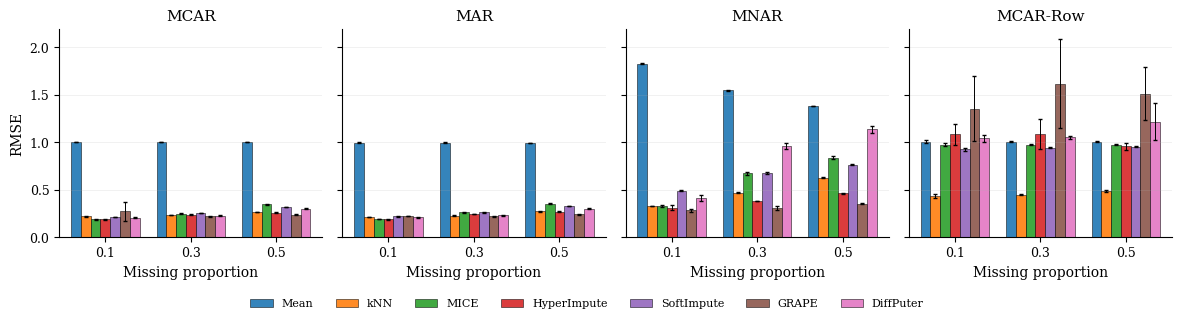

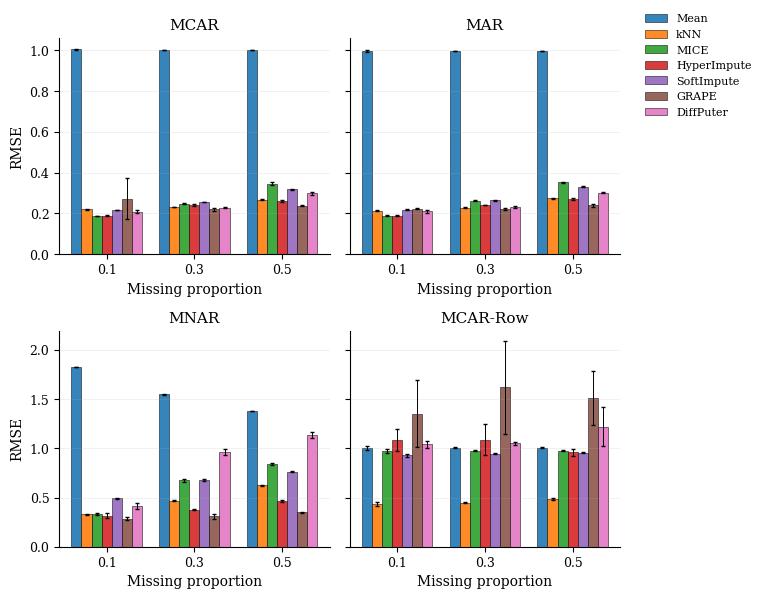

'\\begin{tabular}{lcccc}\n\\toprule\n & Wasserstein & Mean shift & Var.\\ retention & Corr.\\ Frob. \\\\\nMethod &  &  &  &  \\\\\n\\midrule\nMean & 0.789 $\\pm$ 0.001 & 0.027 $\\pm$ 0.002 & 0.000 $\\pm$ 0.000 & 10.814 $\\pm$ 0.026 \\\\\nkNN & 0.033 $\\pm$ 0.001 & 0.019 $\\pm$ 0.002 & 0.942 $\\pm$ 0.003 & 0.550 $\\pm$ 0.034 \\\\\nMICE & 0.050 $\\pm$ 0.001 & 0.007 $\\pm$ 0.000 & 0.908 $\\pm$ 0.002 & 0.370 $\\pm$ 0.016 \\\\\nHyperImpute & \\textbf{0.030 $\\pm$ 0.001} & 0.007 $\\pm$ 0.000 & 0.969 $\\pm$ 0.005 & \\textbf{0.308 $\\pm$ 0.008} \\\\\nSoftImpute & 0.099 $\\pm$ 0.001 & \\textbf{0.005 $\\pm$ 0.000} & 0.783 $\\pm$ 0.001 & 1.238 $\\pm$ 0.034 \\\\\nGRAPE & 0.041 $\\pm$ 0.006 & 0.019 $\\pm$ 0.006 & 0.956 $\\pm$ 0.037 & 0.751 $\\pm$ 0.180 \\\\\nDiffPuter & 0.037 $\\pm$ 0.003 & 0.023 $\\pm$ 0.003 & \\textbf{0.979 $\\pm$ 0.003} & 0.470 $\\pm$ 0.046 \\\\\n\\bottomrule\n\\end{tabular}\n'

In [11]:
from common.visualization import plot_metric_bars, err_table, stat_fidelity_table, plot_2x2_grid

RECON_CSV = CSV_DIR / f"{spec.name}_imputation_results.csv"

# Persist this run, then read back from CSV so plots/tables are reproducible
# from disk (uncomment the first time, or whenever you re-run the sweep).
# results_df.to_csv(RECON_CSV, index=False)
data_source = RECON_CSV if RECON_CSV.exists() else results_df

scenario_filter = ["MCAR", "MAR", "MNAR", "MCAR-Row"]
plot_metric_bars(data_source, "rmse", "RMSE", scenarios=["MCAR", "MAR", "MNAR", "MCAR-Row"],
                 filename=FIGURES_DIR / f"{spec.name}_rmse.png")
plot_2x2_grid(
    data_source, "rmse", "RMSE",
    scenarios=["MCAR", "MAR", "MNAR", "MCAR-Row"],
    ncols=2,
    sharey="row",
    filename=FIGURES_DIR / f"{spec.name}_rmse.png",
)
for mech in ["MCAR", "MAR", "MNAR", "MCAR-Row"]:
    display(err_table(data_source, mech))

display(stat_fidelity_table(data_source, scenario="MCAR", proportion=0.3, latex=True))

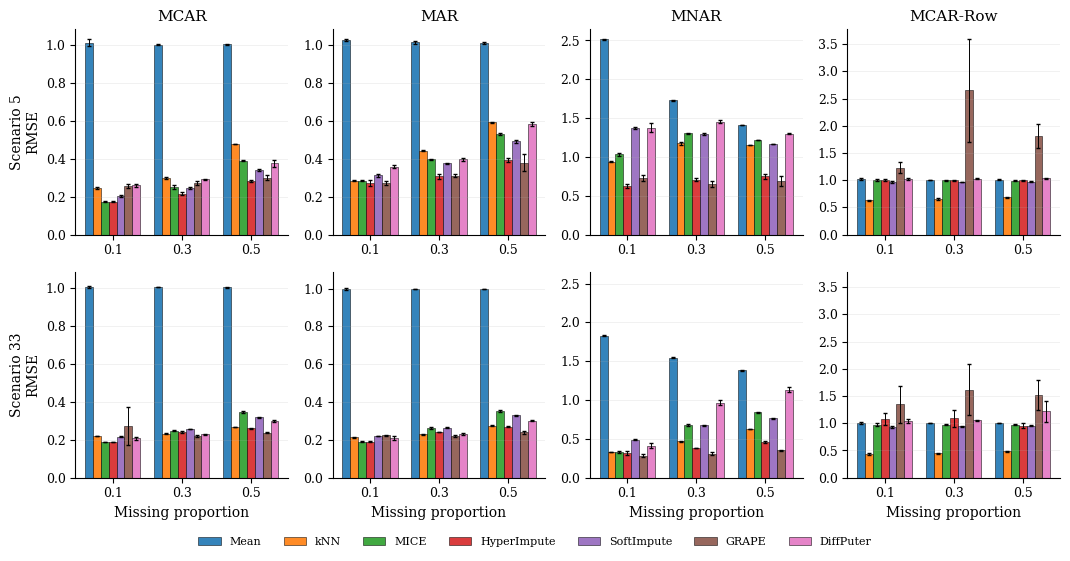

\begin{tabular}{llcccc}
\toprule
 &  & Wasserstein & Mean shift & Var.\ retention & Corr.\ Frob. \\
Dataset & Method &  &  &  &  \\
\midrule
\multirow[t]{7}{*}{Scenario 5} & Mean & 0.630 $\pm$ 0.001 & 0.036 $\pm$ 0.002 & 0.000 $\pm$ 0.000 & 5.819 $\pm$ 0.016 \\
 & kNN & 0.053 $\pm$ 0.000 & 0.030 $\pm$ 0.001 & 0.814 $\pm$ 0.003 & 0.512 $\pm$ 0.029 \\
 & MICE & 0.048 $\pm$ 0.001 & 0.008 $\pm$ 0.001 & 0.896 $\pm$ 0.009 & 0.355 $\pm$ 0.016 \\
 & HyperImpute & \textbf{0.031 $\pm$ 0.001} & 0.008 $\pm$ 0.001 & \textbf{0.945 $\pm$ 0.008} & \textbf{0.336 $\pm$ 0.017} \\
 & SoftImpute & 0.077 $\pm$ 0.001 & \textbf{0.006 $\pm$ 0.001} & 0.769 $\pm$ 0.003 & 0.556 $\pm$ 0.049 \\
 & GRAPE & 0.087 $\pm$ 0.022 & 0.053 $\pm$ 0.030 & 0.900 $\pm$ 0.013 & 0.892 $\pm$ 0.047 \\
 & DiffPuter & 0.054 $\pm$ 0.005 & 0.028 $\pm$ 0.009 & 1.070 $\pm$ 0.006 & 0.592 $\pm$ 0.020 \\
\cline{1-6}
\multirow[t]{7}{*}{Scenario 33} & Mean & 0.789 $\pm$ 0.001 & 0.027 $\pm$ 0.002 & 0.000 $\pm$ 0.000 & 10.814 $\pm$ 0.026 \\
 & 

In [15]:
from common.visualization import stat_fidelity_table_multi, plot_metric_bars_datasets
scenario5_csv = CSV_DIR / "scenario5_imputation_results.csv"
scenario33_csv = CSV_DIR / "scenario33_imputation_results.csv"

latex = stat_fidelity_table_multi(
    {"Scenario 5": scenario5_csv, "Scenario 33": scenario33_csv},
    scenario="MCAR", proportion=0.3, latex=True)


plot_metric_bars_datasets(
    {"Scenario 5": scenario5_csv, "Scenario 33": scenario33_csv},
    metric="rmse", ylabel="RMSE", filename=FIGURES_DIR / "rmse.png",)

print(latex)